# Hybrid levels to pressure levels

For a hybrid-sigma field, `.x.get_plev()` interpolates to pressure levels using the
surface pressure and the hybrid coefficients in the file. This needs `geocat-comp`,
which is an optional dependency.

The sample ships `T` for year 1 only (a 3-D atmosphere field is far larger than a
2-D one), so this selects that span.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
fpath_T = os.path.join(
    case_dir, 'atm', 'proc', 'tseries', 'month_1',
    f'{casename}.cam.h0.T.000101-000112.nc',
)
fpath_PS = os.path.join(
    case_dir, 'atm', 'proc', 'tseries', 'month_1',
    f'{casename}.cam.h0.PS.000101-000512.nc',
)

ds_T = x4c.open_dataset(fpath_T, comp='atm', grid='ne16np4', vn='T', shift_time=True)
ds_PS = x4c.open_dataset(fpath_PS, comp='atm', grid='ne16np4', vn='PS', shift_time=True)

# `T` in the sample covers year 1 only while `PS` covers years 1-5, so line the two
# up before interpolating -- geocat needs them on the same time axis
ds_PS = ds_PS.sel(time=ds_T.time)
print('T  dims:', dict(ds_T.x.da.sizes))
print('PS dims:', dict(ds_PS.x.da.sizes))

T  dims: {'time': 12, 'lev': 30, 'ncol': 13826}
PS dims: {'time': 12, 'ncol': 13826}


after get_plev: {'time': 12, 'plev': 2, 'ncol': 13826}


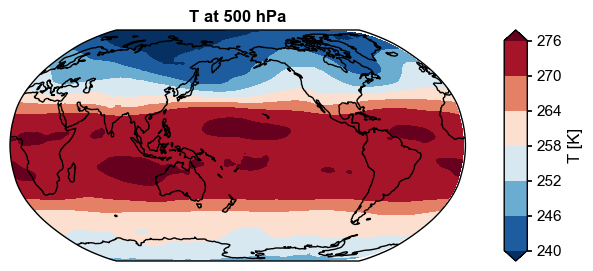

In [3]:
try:
    ds_plev = ds_T.x.get_plev(ps=ds_PS, new_levels=np.array([50000.0, 85000.0]))
    T_plev = ds_plev.x.da
    print('after get_plev:', dict(T_plev.sizes))
    fig, ax = T_plev.isel(time=0, plev=0).x.plot(title='T at 500 hPa')
    x4c.showfig(fig)
except ImportError as e:
    print('skipped:', e)